In [287]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [288]:
def compute_spectra(bins, v, ndft):
    sfdr = np.zeros(len(bins))
    hd3 = np.zeros(len(bins))
    spec_dbv_out = np.zeros((len(bins), ndft//2+1))
    for i in bins:
        y = v[i-1, :]
        y = y[:-1]
        relative_error = (y[-1]-y[-1-ndft])/y[-1]
        print(relative_error)
        y = y[-ndft:]
        spec = np.fft.rfft(y)
        spec_dbv = 20*np.log10(np.abs(spec)/(ndft/2))
        spec_dbv_out[i-1, :] = spec_dbv
        sfdr[i-1] = spec_dbv[i] - np.max(np.delete(spec_dbv, [0, i]))
        hd3[i-1] = spec_dbv[i] - spec_dbv[get_third_harmonic_bin(i, ndft)]
    return sfdr, hd3, spec_dbv_out

In [289]:
def get_third_harmonic_bin(i, ndft):
    """
    Finds the 3rd harmonic bin for a real-valued signal.
    i: fundamental bin index
    nfft: total number of FFT points
    """
    # Step 1: Wrap around the sampling frequency
    wrapped_bin = (3 * i) % ndft
    
    # Step 2: Fold back if it's above Nyquist
    if wrapped_bin > ndft // 2:
        harmonic_bin = ndft - wrapped_bin
    else:
        harmonic_bin = wrapped_bin
        
    return int(harmonic_bin)

In [290]:
df1 = pd.read_csv('./xschem/simulation/tb_boot_bottom_diff.txt', sep='\\s+')
df1

,time,v(vip),v(vop),v(von)
0,1.900000e-09,0.657402,0.632070,0.566974
1,3.900000e-09,0.715501,0.691732,0.508162
2,5.900000e-09,0.768871,0.747291,0.452509
3,7.900000e-09,0.815327,0.796839,0.402909
4,9.900000e-09,0.852968,0.838356,0.361391
...,...,...,...,...
103,6.390000e-08,0.763799,0.695569,0.504248
104,6.590000e-08,0.878021,0.840387,0.358796
105,6.790000e-08,0.892579,0.899533,0.300244
106,6.990000e-08,0.802255,0.851617,0.349259


In [291]:
# Parameters
fs = 500e6
ndft = 31
runs = 3
bins = np.arange(1, runs+1)

In [292]:
vip = np.reshape(df1['v(vip)'].values, [runs, len(df1)//runs])
vop = np.reshape(df1['v(vop)'].values, [runs, len(df1)//runs])
von = np.reshape(df1['v(von)'].values, [runs, len(df1)//runs])
vod = vop - von

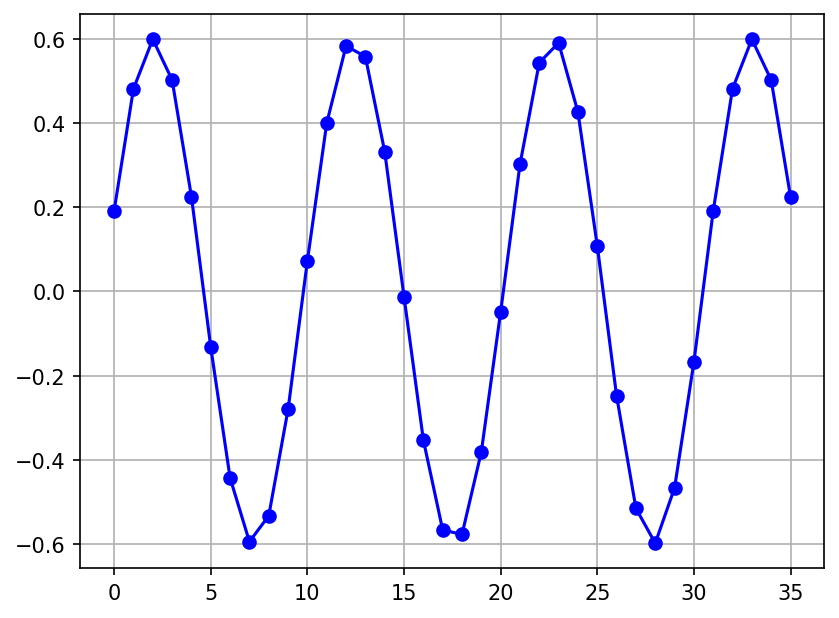

In [293]:
plt.plot(vod[2, :], "b-o")
plt.grid()
plt.show()

In [294]:
hd3_vip = compute_spectra(bins, vip, ndft)[1]
hd3_vop = compute_spectra(bins, vop, ndft)[1]
hd3_vod = compute_spectra(bins, vod, ndft)[1]

1.4227412955137661e-08
5.456394455409827e-08
9.946957382454326e-08
4.220285037338234e-06
-2.448298855264872e-07
3.6765365471347084e-07
1.7036520758534366e-05
-7.183938242978003e-07
1.1935714733006705e-06


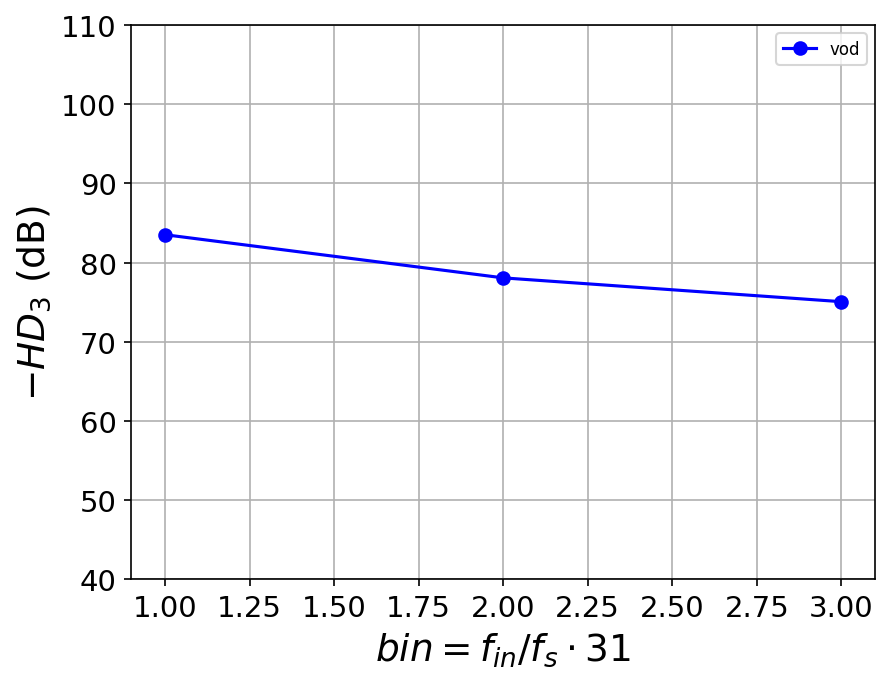

In [295]:
plt.rcParams['figure.dpi'] = 150
#plt.plot(bins, hd3_vip, "r--", label='vi')
#plt.plot(bins, hd3_vop, "g-o", label='vop')
plt.plot(bins, hd3_vod, "b-o", label='vod')
    
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("$-HD_3$ (dB)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(40, 110)
plt.grid(True)
plt.legend(fontsize=8)
plt.show()

1.7036520758534366e-05
-7.183938242978003e-07
1.1935714733006705e-06


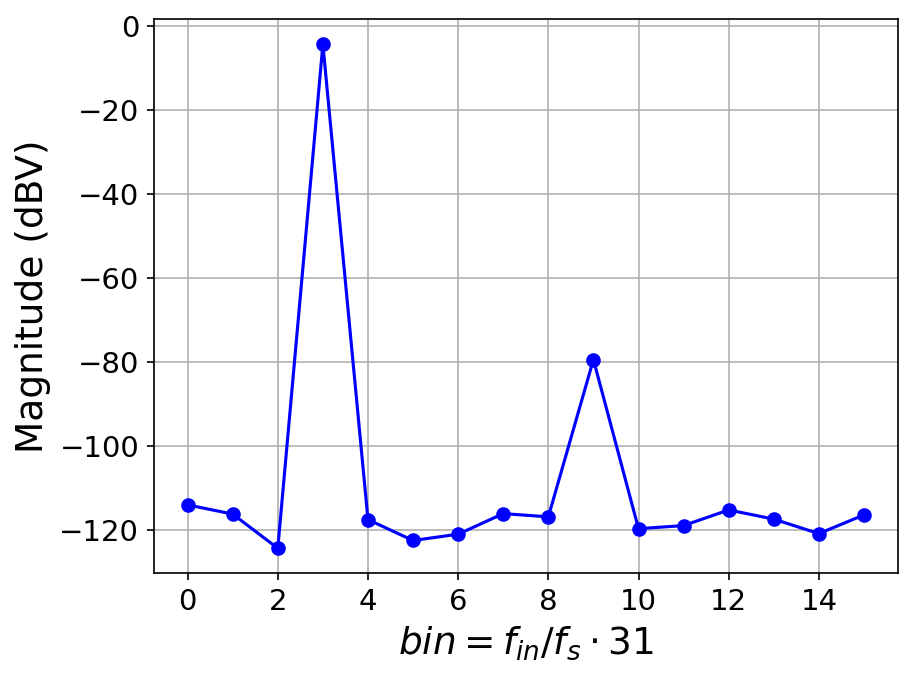

In [296]:
spec_dbv_out = compute_spectra(bins, vod, ndft)[2]

plt.plot(spec_dbv_out[2, :], "b-o")
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("Magnitude (dBV)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.ylim(25, 72)
plt.grid(True)
plt.show()
